# Perceptron from Scratch
## CMOR 438 / INDE 577 — Qiushi Han

The **Perceptron** is the simplest neural network. It is a single-layer linear classifier introduced by Rosenblatt in 1958. It makes binary predictions using:

$$\hat{y} = \begin{cases} 1 & \text{if } w \cdot x + b \geq 0 \\ 0 & \text{otherwise} \end{cases}$$

Training uses the **Perceptron learning rule**: for each misclassified point, update the weights:

$$w \leftarrow w + \eta(y - \hat{y})x$$

The Perceptron is guaranteed to converge **if and only if the data is linearly separable**.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.model_selection import train_test_split as sklearn_split

from rice_ml.supervised_learning.perceptron import Perceptron
from rice_ml.processing.metrics import accuracy_score, confusion_matrix
from rice_ml.processing.preprocessing import StandardScaler

## Loading and Exploring the Dataset

We use the **Breast Cancer Wisconsin dataset** — 569 samples, 30 features, binary classification (malignant vs benign). This is a real medical dataset making it a meaningful test for the perceptron's ability to find a linear decision boundary.

In [15]:
data = load_breast_cancer()
X = data.data
y = data.target

print(f"Dataset shape: {X.shape}")
print(f"Class distribution: {np.bincount(y)}")
print(f"Positive class (benign): {(y == 1).sum()}")
print(f"Negative class (malignant): {(y == 0).sum()}")

Dataset shape: (569, 30)
Class distribution: [212 357]
Positive class (benign): 357
Negative class (malignant): 212


## Preprocessing and Train/Test Split

In [16]:
X_train, X_test, y_train, y_test = sklearn_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 455
Test samples: 114


## Training the Perceptron

In [17]:
model = Perceptron(learning_rate=0.1, max_iter=100)
print("Training Perceptron...")
model.fit(X_train_scaled, y_train)
print("Training Complete.")
print(f"\nLearned weights: {model.coef_}")
print(f"Learned bias: {model.intercept_:.4f}")

Training Perceptron...
Training Complete.

Learned weights: [-0.15806312 -0.07568661 -0.12519494 -0.46032947 -0.45258246  3.40703274
 -1.44153691 -0.96521928  0.42780644 -1.26197705 -1.17430016  0.49443767
  0.77188476 -2.02265118 -0.33958138 -0.96938048  3.01515403 -1.48287114
  0.27172313  0.85770861 -0.9546536  -1.46914814 -0.16550424 -1.65203337
 -0.11042774  0.42667999 -2.72171099  0.07353762 -1.41346382  0.72809568]
Learned bias: -0.4000


## Evaluation

In [18]:
y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"\nConfusion Matrix:\n{cm}")

Accuracy: 0.9474

Confusion Matrix:
[[39  3]
 [ 3 69]]


## Decision Boundary Visualization

To visualize the perceptron's decision boundary we train on just the first two features (mean radius and mean texture).

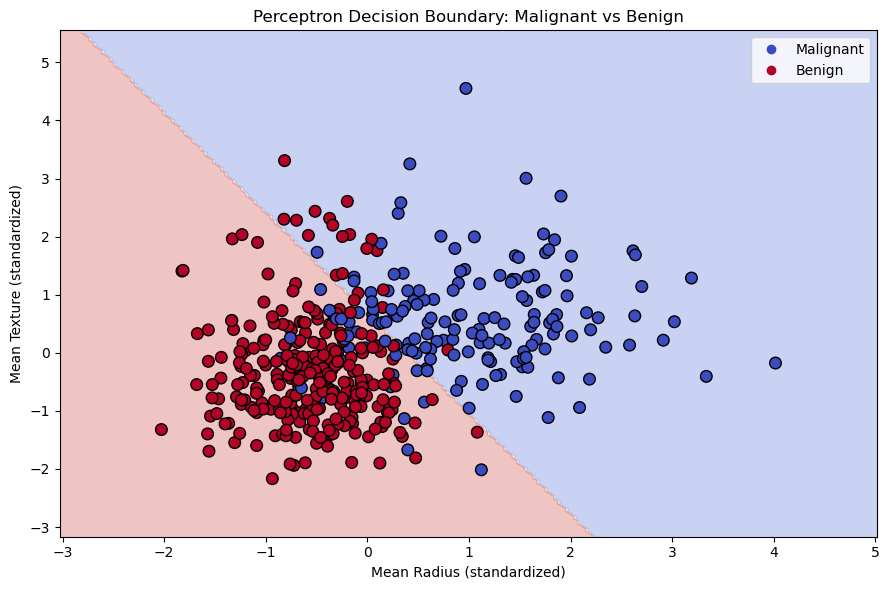

In [19]:
X_2d = X[:, :2]
X_train_2d, X_test_2d, y_train_2d, y_test_2d = sklearn_split(
    X_2d, y, test_size=0.2, random_state=42, stratify=y)

scaler_2d = StandardScaler().fit(X_train_2d)
X_train_2d_scaled = scaler_2d.transform(X_train_2d)

model_2d = Perceptron(learning_rate=0.1, max_iter=100).fit(
    X_train_2d_scaled, y_train_2d)

x_min, x_max = X_train_2d_scaled[:, 0].min() - 1, X_train_2d_scaled[:, 0].max() + 1
y_min, y_max = X_train_2d_scaled[:, 1].min() - 1, X_train_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
scatter = plt.scatter(X_train_2d_scaled[:, 0], X_train_2d_scaled[:, 1],
                      c=y_train_2d, cmap='coolwarm', edgecolors='k', s=70)
plt.xlabel('Mean Radius (standardized)')
plt.ylabel('Mean Texture (standardized)')
plt.title('Perceptron Decision Boundary: Malignant vs Benign')
plt.legend(handles=scatter.legend_elements()[0],
           labels=['Malignant', 'Benign'])
plt.tight_layout()
plt.show()

## Comparison: Linearly Separable vs Non-Separable Data

The perceptron only converges on linearly separable data. Now it is important to observe what happens when we try to classify a harder, overlapping dataset.

In [20]:
# Generate a non-linearly separable dataset
X_hard, y_hard = make_classification(
    n_samples=200, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=2,
    class_sep=0.5, random_state=42)

X_h_train, X_h_test, y_h_train, y_h_test = sklearn_split(
    X_hard, y_hard, test_size=0.2, random_state=42)

scaler_h = StandardScaler().fit(X_h_train)
X_h_train_scaled = scaler_h.transform(X_h_train)
X_h_test_scaled = scaler_h.transform(X_h_test)

model_hard = Perceptron(learning_rate=0.1, max_iter=100).fit(
    X_h_train_scaled, y_h_train)

acc_hard = accuracy_score(y_h_test, model_hard.predict(X_h_test_scaled))
print(f"Accuracy on hard (non-separable) dataset: {acc_hard:.4f}")
print(f"(Compare to setosa accuracy of {acc:.4f})")

Accuracy on hard (non-separable) dataset: 0.6250
(Compare to setosa accuracy of 0.9474)


## Discussion

- The Perceptron achieves **94.74% accuracy** on the Breast Cancer dataset, correctly classifying 108 out of 114 test samples
- The confusion matrix shows only 6 misclassifications, with 3 false positives (benign predicted as malignant) and 3 false negatives (malignant predicted as benign)
- In a medical context, false negatives are more dangerous than false positives since missing a malignant tumor is more harmful than a false alarm, making this an important consideration beyond just accuracy
- The learned weight vector has 30 values, one per feature, showing how much each chemical measurement contributes to the final classification decision
- The **decision boundary visualization** uses only the first two features (mean radius and mean texture) to allow 2D plotting, which is why the boundary appears as a single straight diagonal line
- Larger mean radius and higher mean texture are associated with malignant classification while lower values lean toward benign, which aligns with medical intuition since larger tumors tend to be more dangerous
- The overlap near the center of the plot shows more misclassifications than the true model produces, because the visualization only uses 2 of the 30 features available to the full model
- It is worth noting that the decision boundary plot uses only 2 of the 30 features, so more overlap appears in the visualization than actually exists in the full model. The true separation happens in 30-dimensional space where the perceptron achieves 94.74% accuracy
- With all 30 features available during training, the perceptron achieves 94.74% showing the data is largely linearly separable in the full 30-dimensional feature space
- On the **non-linearly separable synthetic dataset**, accuracy drops to 62.50%, again confirming that the perceptron only works well when classes can be separated by a straight line
- **Strengths** include simplicity, fast training, and good performance on linearly separable high-dimensional data like this medical dataset
- **Weaknesses** include inability to handle non-linear boundaries and sensitivity to the order of training samples